In [1]:
import hoda
import tensorly as tl
tl.get_backend()

'cupy'

In [2]:
from hoda import backend
import seaborn as sns
import matplotlib.pyplot as plt
import math


In [3]:
from moabb.paradigms import P300
from moabb.datasets import *
from mne.decoding import Scaler

tmin = 0
tmax=0.8
fmin=0.5
fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
dataset = BNCI2014_009()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)
session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]

scaler = Scaler(scalings='mean', with_mean=False)
epochs._data = scaler.fit_transform(epochs._data)

<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_channels_regexp is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.channel_type is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
/usr/local/lib/python3.10/dist-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(


To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
1728 matching events found
No baseline correction applied


/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:354: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [4]:
epochs

Number of events,576
Events,NonTarget: 480Target: 96
Time range,0.000 – 0.781 s
Baseline,off


In [5]:
meta

,subject,session,run
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
571,1,0,0
572,1,0,0
573,1,0,0
574,1,0,0


In [6]:
X = epochs.get_data()
y = labels

X.shape

/tmp/ipykernel_12458/2444922706.py:1: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs.get_data()


(576, 16, 26)

In [7]:
from hoda.hoda import HODA
import warnings



hoda = HODA(
            rank=5,
            max_iter=256,
            tol=1e-8,
            init ='svd',
            shrinkage='lw',
            toeplitz=None,
            obj='rt',
            solver='lanczos',
            taper=False,
            keep_train_info=False,
            verbose=True,
        )

hoda.fit(X,y)

Initializing factors...
Fitting discriminative Tucker model...


  0%|          | 0/256 [00:00<?, ?it/s]

Fitted Tucker model of rank (5, 5) ...


HODA(rank=5, verbose=True)

In [8]:
import math
import matplotlib.pyplot as plt
from hoda.cov import center


X = tl.tensor(X)
Xt = hoda.transform(X)

_, Xc = center(X,y)
_, Xtc = center(Xt,y)

(16, 26, 5, 5)


<Axes: >

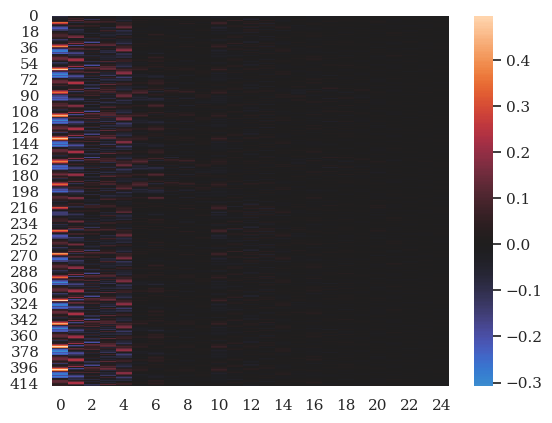

In [9]:
cross_cov_full = tl.tenalg.tensordot(Xc, Xt, modes=(0,))/(X.shape[0]-1)
print(cross_cov_full.shape)
sns.heatmap(tl.to_numpy(cross_cov_full.reshape(math.prod(X.shape[1:]),-1)), center=0)

(16, 26, 5, 5)


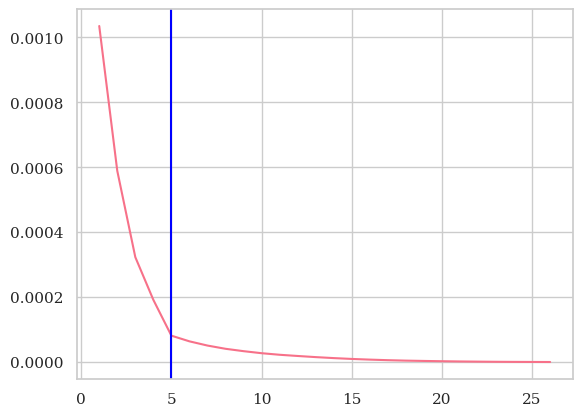

In [28]:
from hoda.hoda import mse
mses = []
x = list(range(1,max(X.shape[1:])+1))
print(cross_cov_full.shape)
for r in x:
    (core,factors),_ = tl.decomposition.partial_tucker(cross_cov_full, r, modes=(0,1))
    A_rec = tl.tenalg.multi_mode_dot(core, factors, transpose=False, modes=[0,1])
    mses.append(float(mse(cross_cov_full, A_rec)))
plt.plot(x,mses)
plt.axvline(hoda.rank, color='blue')

In [29]:
sns.heatmap(tl.to_numpy(hoda.cov_cross_[:,:,1,1]), center=0)

TypeError: tuple indices must be integers or slices, not tuple

In [ ]:
import numpy as np
from mne.viz import plot_topomap
col_wrap=n_col=4
n_row = int(np.ceil(hoda.rank_(0) / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
A = factors[2]@factors[0].T
for i in range(hoda.rank_(0)):
    a = tl.to_numpy(A[:,i])
    plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False)


n_row = int(np.ceil(hoda.rank_(1) / col_wrap)) 
fig, axs = plt.subplots(
    n_row, n_col, 
    layout='tight', 
    sharex=True,
    sharey=True
)
A = factors[3]@factors[1].T
for i in range(hoda.rank_(1)):
    a = tl.to_numpy(A[:,i])
    axs.flatten()[i].plot(epochs.times, a)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Amplitude');


In [ ]:
from hoda.cov import KroneckerCovariance
import matplotlib.pyplot as plt
order=2

cross_cov_kron = KroneckerCovariance(assume_centered=True)
cross_cov_kron.fit(Xc, Xtc)

norm = tl.mean(tl.tensor([tl.mean(tl.abs(cross_cov_kron.covs_[k])) for k in range(order)]))
kron = tl.kron(*cross_cov_kron.covs_)*cross_cov_kron.scale_
sns.heatmap(tl.to_numpy(kron), center=0)
plt.show()
order=2
fig, axs = plt.subplots(order, 2)

for k in range(order):
    sns.heatmap(tl.to_numpy(cross_cov_kron.covs_[k]), center=0, ax=axs[k,0])
    sns.heatmap(tl.to_numpy(cross_cov_kron.precs_[k]), center=0, ax=axs[k,1])
    axs[0,k].set_aspect('equal')


In [ ]:


_, Xt_centered = center(Xt, y, hoda.classes_)

G_cov = tl.tensordot(Xt_centered.T, Xt_centered, axes=1)
G_cov /= X.shape[0] - 1
G_cov_r = G_cov.reshape(math.prod(hoda.ml_rank_), -1)
G_cov_r_inv = backend.np.linalg.pinv(G_cov_r)
G_cov_inv = G_cov_r_inv.reshape((*hoda.ml_rank_, *hoda.ml_rank_))
sns.heatmap(tl.to_numpy(G_cov_r), center=0)
plt.show()
sns.heatmap(tl.to_numpy(G_cov_r_inv), center=0)

In [ ]:
import numpy as np
from mne.viz import plot_topomap

col_wrap=4
n_col=col_wrap

n_row = int(np.ceil(hoda.rank_(0) / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
A = kron_cov.covs_[0]
for i in range(hoda.rank_(0)):
    a = tl.to_numpy(A[:,i])
    plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False)


n_row = int(np.ceil(hoda.rank_(1) / col_wrap)) 
fig, axs = plt.subplots(
    n_row, n_col, 
    layout='tight', 
    sharex=True,
    sharey=True
)
A = kron_cov.covs_[1]
for i in range(hoda.rank_(1)):
    a = tl.to_numpy(A[:,i])
    axs.flatten()[i].plot(epochs.times, a)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Amplitude');